In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df=pd.read_csv('/content/segmentation data.csv')
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


#DATA INSPECTION

In [5]:
df.shape

(2000, 8)

#Insight
The dataset contains about 2,000 customer records which is plenty for a meaningful customer segmentation analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


#Insight
Cross-checked​‍​‌‍​‍‌ the data types and confirmed that only numerical features were used for clustering. Nothing unexpected was found with the data ​‍​‌‍​‍‌types.

In [7]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


#Insight
Explored central tendency and variability of the numerical variables to gain a better understanding of customer behavior distributions.

In [8]:
df.nunique()

,0
ID,2000
Sex,2
Marital status,2
Age,58
Education,4
Income,1982
Occupation,3
Settlement size,3


In [9]:
df.isnull().sum()

,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


#Insight
There are no missing values found, so the data is clean and complete, making it suitable for analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

#Insight
Checked that there are no duplicate customer records that could cause biased clustering.

In [11]:
df.dtypes

,0
ID,int64
Sex,int64
Marital status,int64
Age,int64
Education,int64
Income,int64
Occupation,int64
Settlement size,int64


#EDA

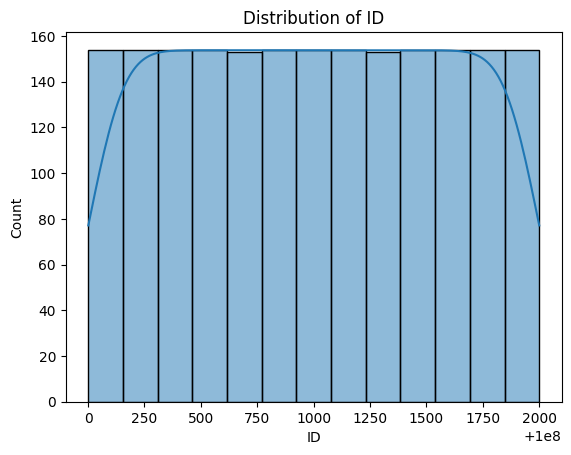

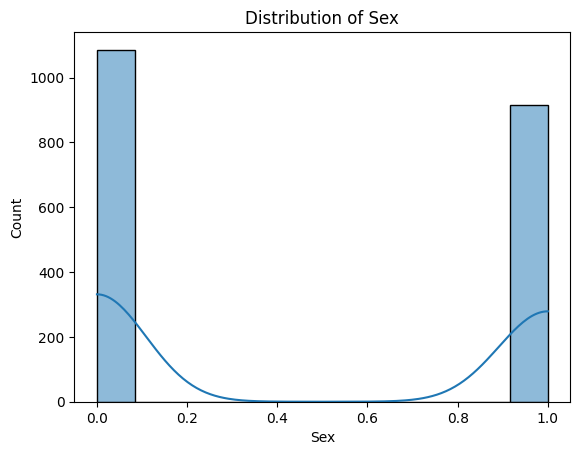

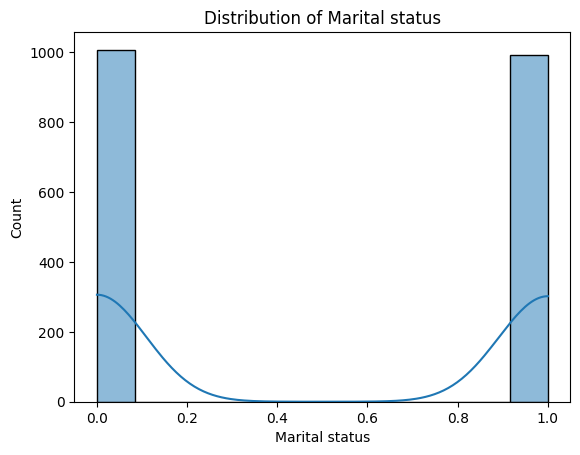

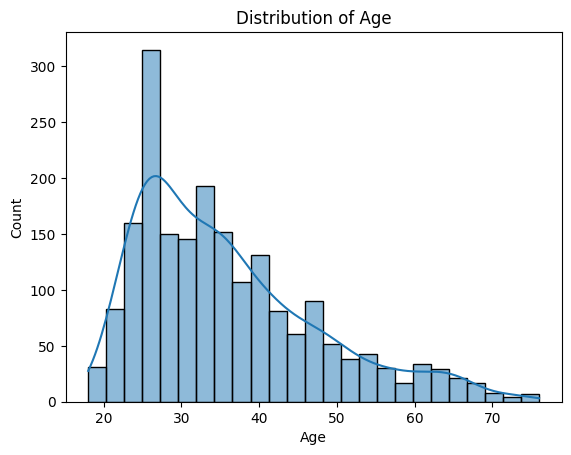

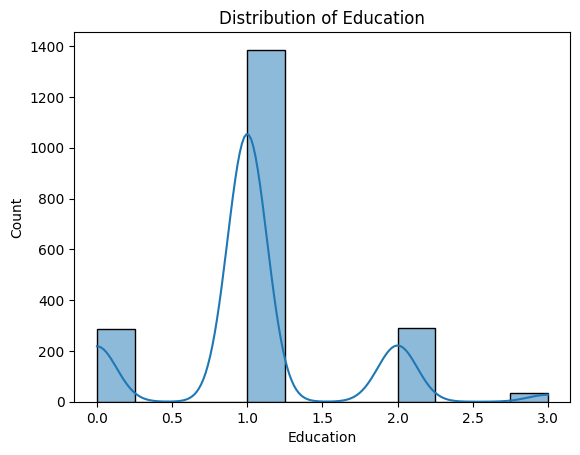

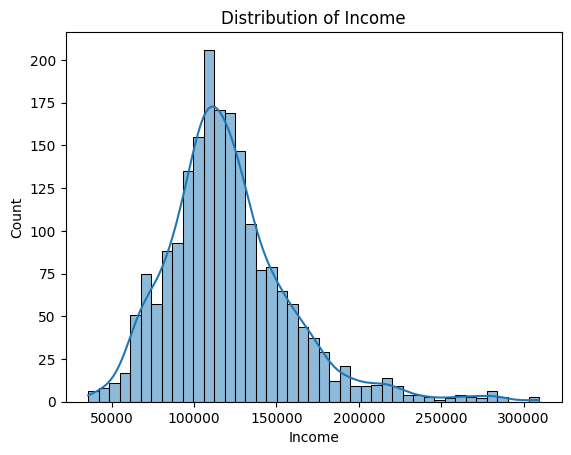

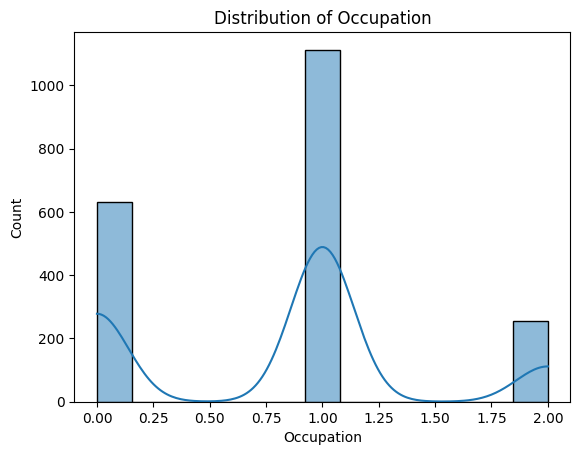

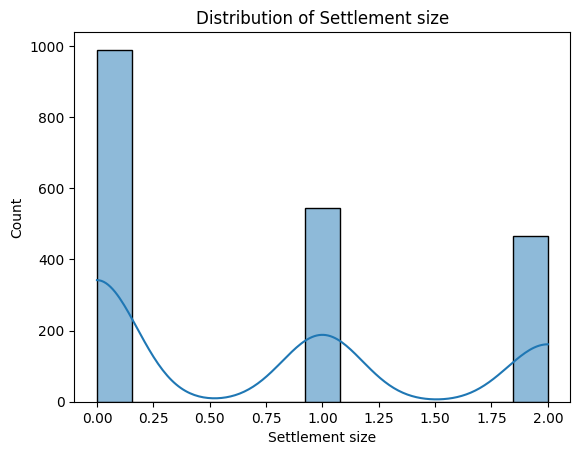

In [12]:
#Distribution of Features (EDA)
for col in df.columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#Insight
Visualized the distribution of features to spot any skewness and variability in customer behaviors.

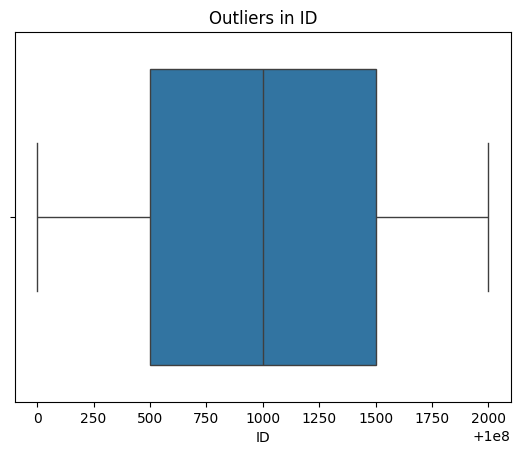

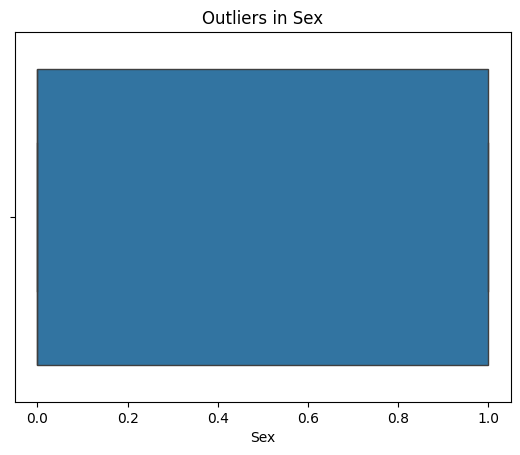

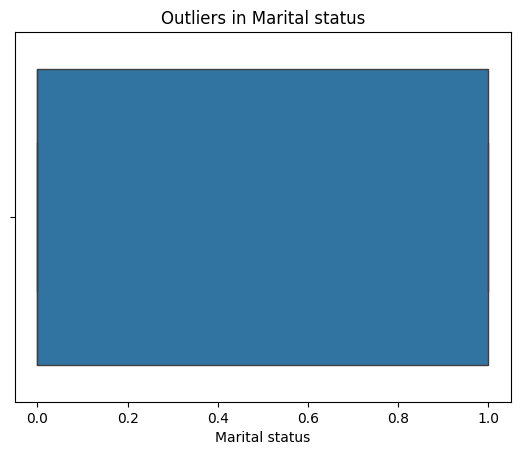

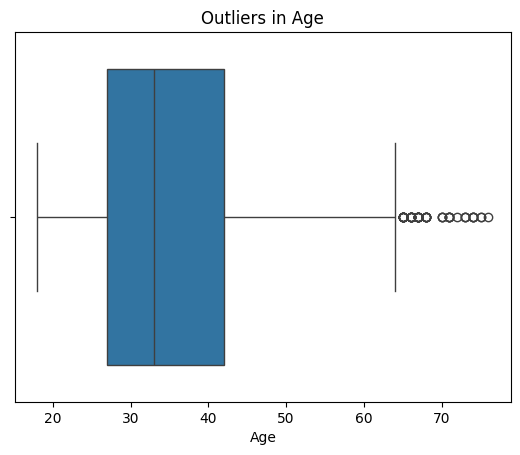

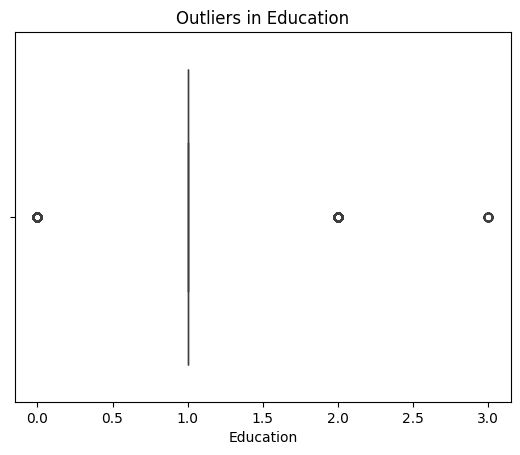

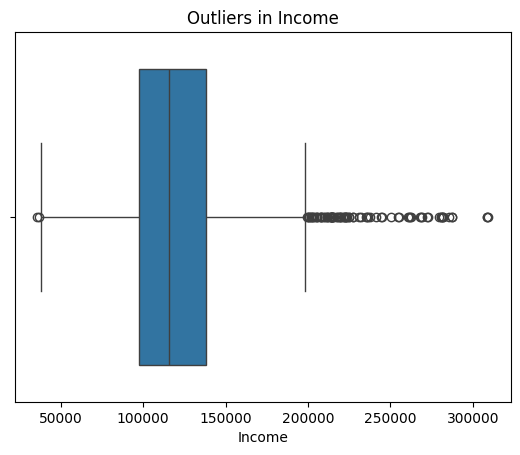

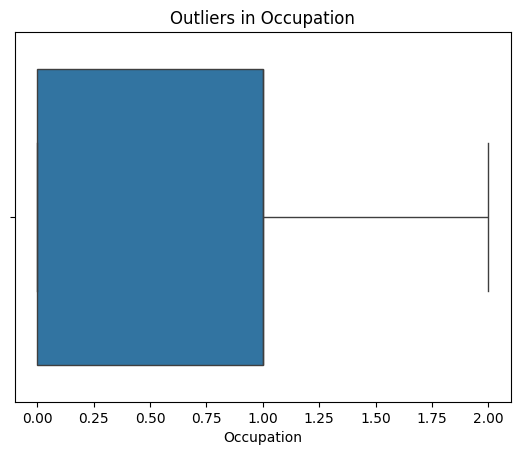

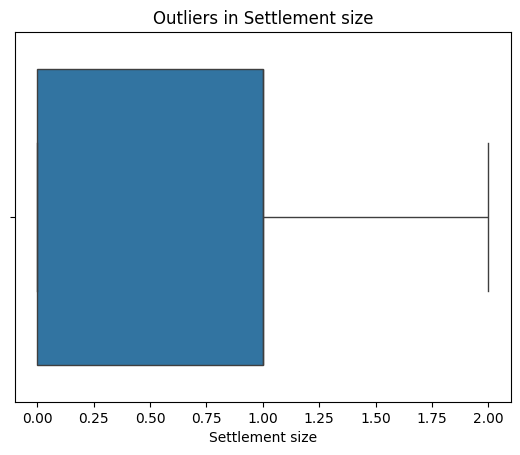

In [13]:
#Boxplots for Outlier Detection
for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()


#Insight

There​‍​‌‍​‍‌ were some unusual points identified that could have had an effect on the results of the distance-based ​‍​‌‍​‍‌clustering.

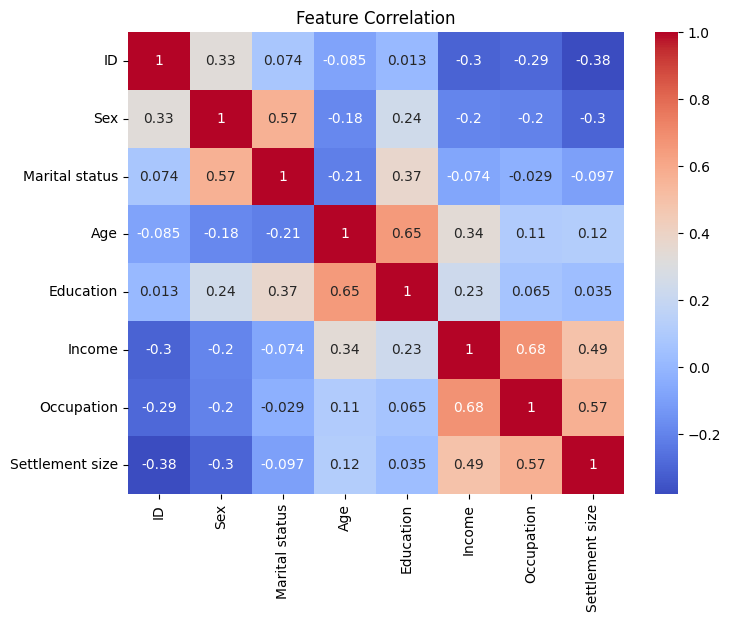

In [14]:
#Feature Correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

#Insight
Investigated relationships between features to see how different customer attributes influence each other.

In [15]:
#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#Insight

Applied standardization to give equal contribution of all features to clustering thus avoiding the situation where features with extremely high magnitude dominate clustering.

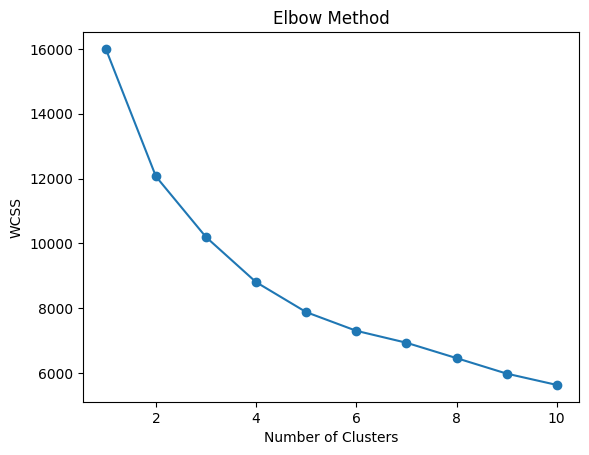

In [16]:
wcss = []           #Elbow Method

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


#Insight

Applied the Elbow Method to decide on the most suitable number of clusters by noticing the point where the WCSS drop starts to slow down.

In [17]:
#Silhouette Score Validation
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'Clusters: {k}, Silhouette Score: {score:.3f}')


Clusters: 2, Silhouette Score: 0.234
Clusters: 3, Silhouette Score: 0.244
Clusters: 4, Silhouette Score: 0.235
Clusters: 5, Silhouette Score: 0.227
Clusters: 6, Silhouette Score: 0.234
Clusters: 7, Silhouette Score: 0.225


#Insight

Validated the quality of clustering by using silhouette scores to make sure the different customer segments were well-separated and meaningful.

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Cluster
0,100000001,0,0,67,2,124670,1,2,2
1,100000002,1,1,22,1,150773,1,2,1
2,100000003,0,0,49,1,89210,0,0,3
3,100000004,0,0,45,1,171565,1,1,0
4,100000005,0,0,53,1,149031,1,1,0


#Insight
Splitting the customers into 4 unique groups according to their behavior patterns.

In [19]:
df['Cluster'].value_counts()

,count
Cluster,
1,679
0,633
3,419
2,269


In [20]:
cluster_profile = df.groupby('Cluster').mean()
cluster_profile

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Cluster,,,,,,,,
0,1.000007e+08,0.031596,0.180095,35.636651,0.737757,140135.807267,1.251185,1.388626
1,1.000011e+08,0.876289,0.998527,29.002946,1.067747,105597.536082,0.630339,0.418262
2,1.000009e+08,0.483271,0.680297,55.881041,2.130112,155931.141264,1.092937,1.078067
3,1.000014e+08,0.403341,0.042959,34.689737,0.742243,94407.322196,0.255370,0.059666


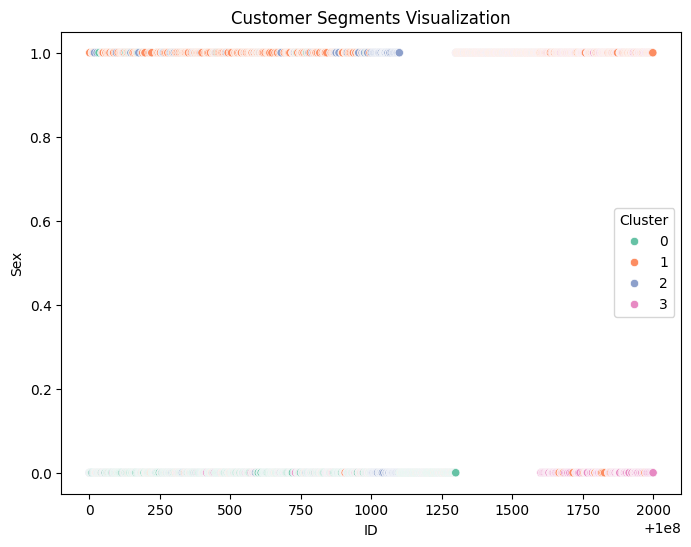

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title('Customer Segments Visualization')
plt.show()

#Insight
- Cluster 0 comprises of high-value customers
- Cluster 1 consists of customers who are sensitive to price
- Cluster 2 indicates potential upsell opportunities
- Cluster 3 comprises moderate, stable customers

Such customer segments could facilitate targeted marketing and personalization strategies.


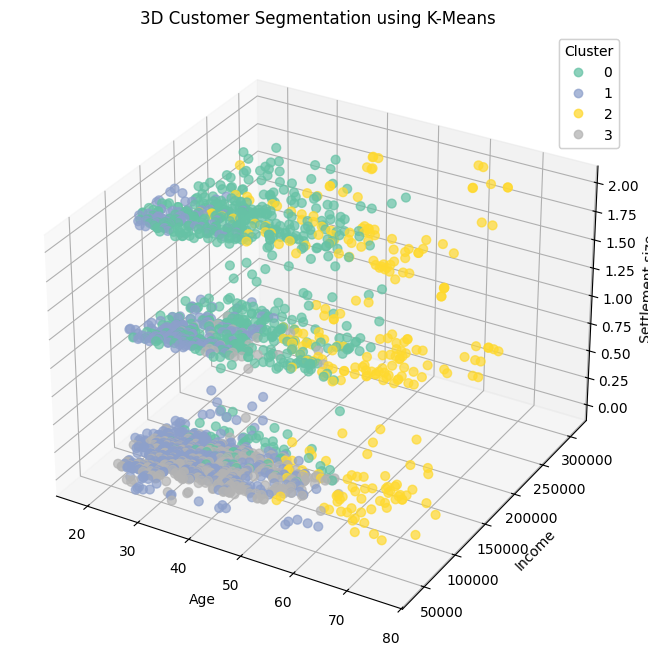

In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Income'],
    df['Settlement size'],
    c=df['Cluster'],
    cmap='Set2',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Settlement size')
ax.set_title('3D Customer Segmentation using K-Means')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()


#Insight

- Customers are segmented based on age, income, and size, forming distinct clusters, establishing that segmentation is done effectively.

- The high income class of customers is mostly found in urban areas, which makes up the luxury segments.

- Customers in small cities are largely from the lower income groups, which makes them price-sensitive.

- There is considerable variation in income levels for similar age groups, with evidence that age is not a determinant of value in customers.

- The size of a settlement has a great impact on income distribution, which means location is a vital element of customers' behavior.

- The clusters overlap by age but are clearly distinguished by income and geographic factors combined.

In [23]:
df.to_csv('customer_segmentation_powerbi.csv', index=False)